Text(0.5, 1.0, 'newspaper vs Sales')

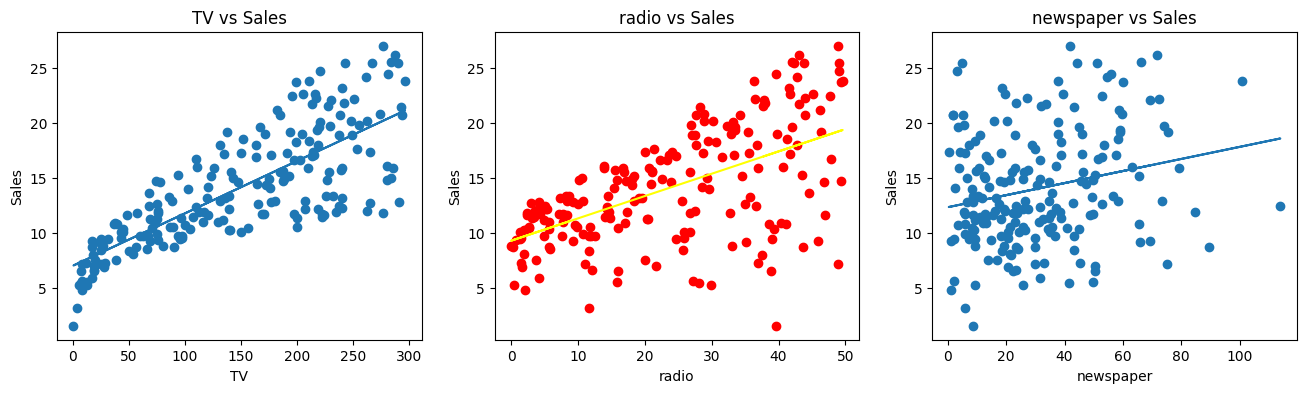

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

data_path = "Advertising.csv"
data_df = pd.read_csv(data_path,index_col=0)

fig = plt.figure(figsize=(16,4))
gs = mpl.gridspec.GridSpec(1,3)

#TV vs Sales
ax = fig.add_subplot(gs[0])
X = data_df['TV'].values
y = data_df['sales'].values
cov_xy = np.cov(X,y)[0][1]
cov_xx = np.cov(X,y)[0][0]
x_mean = np.mean(X)
y_mean = np.mean(y)
m = cov_xy/cov_xx
b = y_mean - m * x_mean
y_pred = m*X + b
ax.scatter(X,y)
ax.plot(X,y_pred)
ax.set_xlabel('TV')
ax.set_ylabel('Sales')
ax.set_title('TV vs Sales')
#radio vs Sales
ax = fig.add_subplot(gs[1])
X = data_df['radio'].values
y = data_df['sales'].values
cov_xy = np.cov(X,y)[0][1]
cov_xx = np.cov(X,y)[0][0]
x_mean = np.mean(X)
y_mean = np.mean(y)
m = cov_xy/cov_xx
b = y_mean - m * x_mean
y_pred = m*X + b
ax.scatter(X,y,color ='red')
ax.plot(X,y_pred,color='yellow')
ax.set_xlabel('radio')
ax.set_ylabel('Sales')
ax.set_title('radio vs Sales')
#newspaper vs Sales
ax = fig.add_subplot(gs[2])
X = data_df['newspaper'].values
y = data_df['sales'].values
cov_xy = np.cov(X,y)[0][1]
cov_xx = np.cov(X,y)[0][0]
x_mean = np.mean(X)
y_mean = np.mean(y)
m = cov_xy/cov_xx
b = y_mean - m * x_mean
y_pred = m*X + b
ax.scatter(X,y)
ax.plot(X,y_pred)
ax.set_xlabel('newspaper')
ax.set_ylabel('Sales')
ax.set_title('newspaper vs Sales')


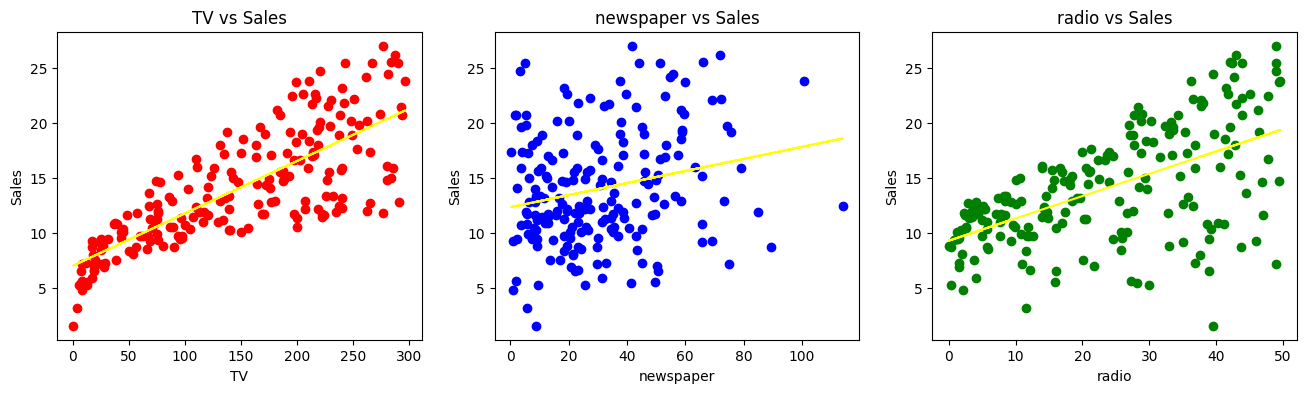

In [21]:
from sklearn.linear_model import LinearRegression
fig = plt.figure(figsize=(16,4))
gs = mpl.gridspec.GridSpec(1,3)
def make_graph(position,element,color):

    #TV vs Sales
    ax = fig.add_subplot(gs[position])
    X = data_df[element].values
    y = data_df['sales'].values
    # cov_xy = np.cov(X,y)[0][1]
    # cov_xx = np.cov(X,y)[0][0]
    # x_mean = np.mean(X)
    # y_mean = np.mean(y)
    # m = cov_xy/cov_xx
    # b = y_mean - m * x_mean
    
    # # From polyfit
    # m,b = np.polyfit(X,y,1)
    # y_pred = m*X + b
    # print (f'y = {m} * x + {b}')
    
    # From sklearn
    linear_model = LinearRegression()
    linear_model.fit(X.reshape(-1,1),y)
    m=linear_model.coef_
    b=linear_model.intercept_
    y_pred = m*X + b
    
    ax.scatter(X,y,color=color)
    ax.plot(X,y_pred,color='yellow')
    ax.set_xlabel(element)
    ax.set_ylabel('Sales')
    ax.set_title(f'{element} vs Sales')
make_graph(0,'TV','red')
make_graph(1,'newspaper','blue')
make_graph(2,'radio','green')

In [20]:

# From sklearn
linear_model = LinearRegression()
linear_model.fit(X.reshape(-1,1),y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Fit a line for
 x = np.array([1,2,3,4,5,6,7,8,9,10]),
 y =np.array([3,5,7,10,15,23,35,50,70,95])

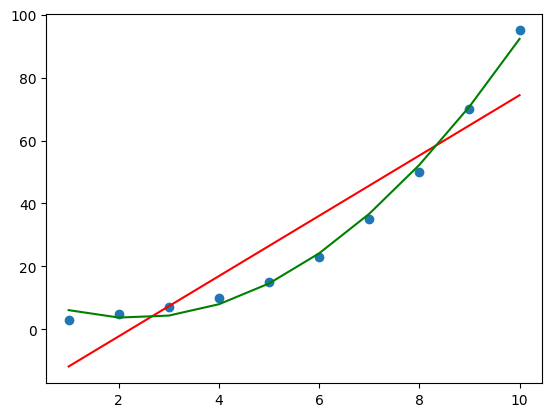

In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([3, 5, 7, 10, 15, 23, 35, 50, 70, 95])

linear_model = LinearRegression()
linear_model.fit(x, y)

polynomial_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
polynomial_model.fit(x,y)
polynomial_predictions = polynomial_model.predict(x)
m = linear_model.coef_
b = linear_model.intercept_
y_pred = m * x + b
plt.scatter(x, y)
plt.plot(x, y_pred, color="red")
plt.plot(x, polynomial_predictions, color="green")

In [35]:
print("Linear Intercept",linear_model.intercept_)
print("Linear Slope",linear_model.coef_)

#Polynomial Regression 
poly_features = polynomial_model.named_steps['polynomialfeatures']
poly_regression = polynomial_model.named_steps['linearregression']
# poly_regression
print("Polynomial Intercept",poly_regression.intercept_)
print("Polynomial Slope",poly_regression.coef_)
print("Polynomial Name of variable",poly_features.get_feature_names_out(["x"]))



Linear Intercept -21.40000000000001
Linear Slope [9.58181818]
Polynomial Intercept 11.433333333333362
Polynomial Slope [ 0.         -6.83484848  1.49242424]
Polynomial Name of variable ['1' 'x' 'x^2']
